# NEXT-100 - MC - 4bar 

Test with Toy MC Kr smample with 'realistic' parameters

Check that the algorithms works with true MC


JA Hernando, 25/02/07

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [2]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [5]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [6]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Fri Jun 13 16:56:50 2025


## Import Data

In [122]:
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/MC/kr'
#path_run = '/250107_4bar/data/kdst'
path_run = '/250203_4bar'


from os import listdir

filenames = listdir(path_data + path_run)
filenames.sort()
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])
filenames = [path_data + path_run + '/' + ifile for ifile in filenames]
filename = '/merged.kdst'

number of files : 3
fist files:  mc4ba4_lt_dtref.png merged.kdst


In [123]:
#kdst = load_dsts(filenames[:1000], "DST", "Events")
# pd.read_hdf(filename, "/RECO/Events")
ifile = path_data + path_run + filename
print('reading ', ifile)
kdst = load_dst(ifile, "DST", "Events")

reading  /Users/hernando/work/investigacion/NEXT/data/NEXT100/MC/kr/250203_4bar/merged.kdst


### Fidutial selection

In [124]:
print('size x ', np.min(kdst.X[kdst.X > -1000.]), np.max(kdst.X))
print('size y ', np.min(kdst.Y[kdst.Y > -1000.]), np.max(kdst.Y))
kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'z', 
                              'DT' : 'dtime', 'R' : 'r'})
print(list(kdst.columns))

size x  -482.625 490.02500000000003
size y  -479.9250000000001 492.7250000000001
['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'energy', 'S2q', 'S2t', 'qmax', 'Nsipm', 'dtime', 'z', 'Zrms', 'x', 'y', 'r', 'Phi', 'Xrms', 'Yrms']


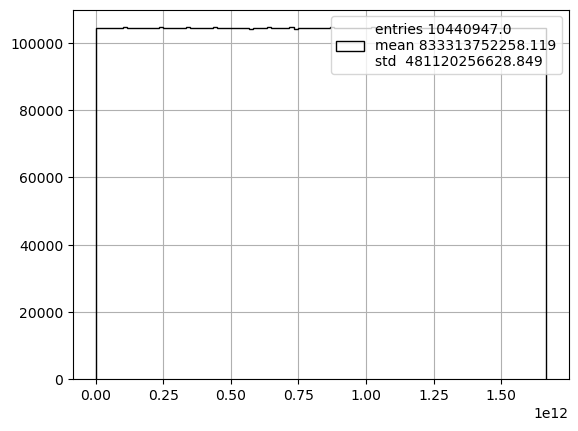

In [125]:
mkdst = kdst
pltext.hist(mkdst.time, 100);

In [126]:
sels = {}
sels['r']        = ut.in_range(mkdst.r  , (0., 500.))
sels['dtime']    = ut.in_range(mkdst.dtime , (0., 1450.))
sels['energy']   = ut.in_range(mkdst.energy, (5e3, 20e4))
sels['fidutial'] = (sels['r']) & (sels['dtime']) & (sels['energy'])

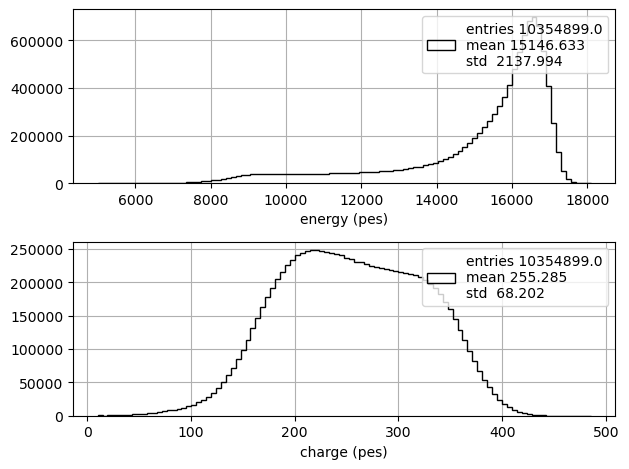

In [127]:
sel = sels['fidutial']
plt.subplot(2, 1, 1)
pltext.hist(kdst[sel].energy, 100); plt.xlabel('energy (pes)')
plt.subplot(2, 1, 2)
pltext.hist(kdst[sel].S2q, 100); plt.xlabel('charge (pes)'); plt.tight_layout()

### Main distributions

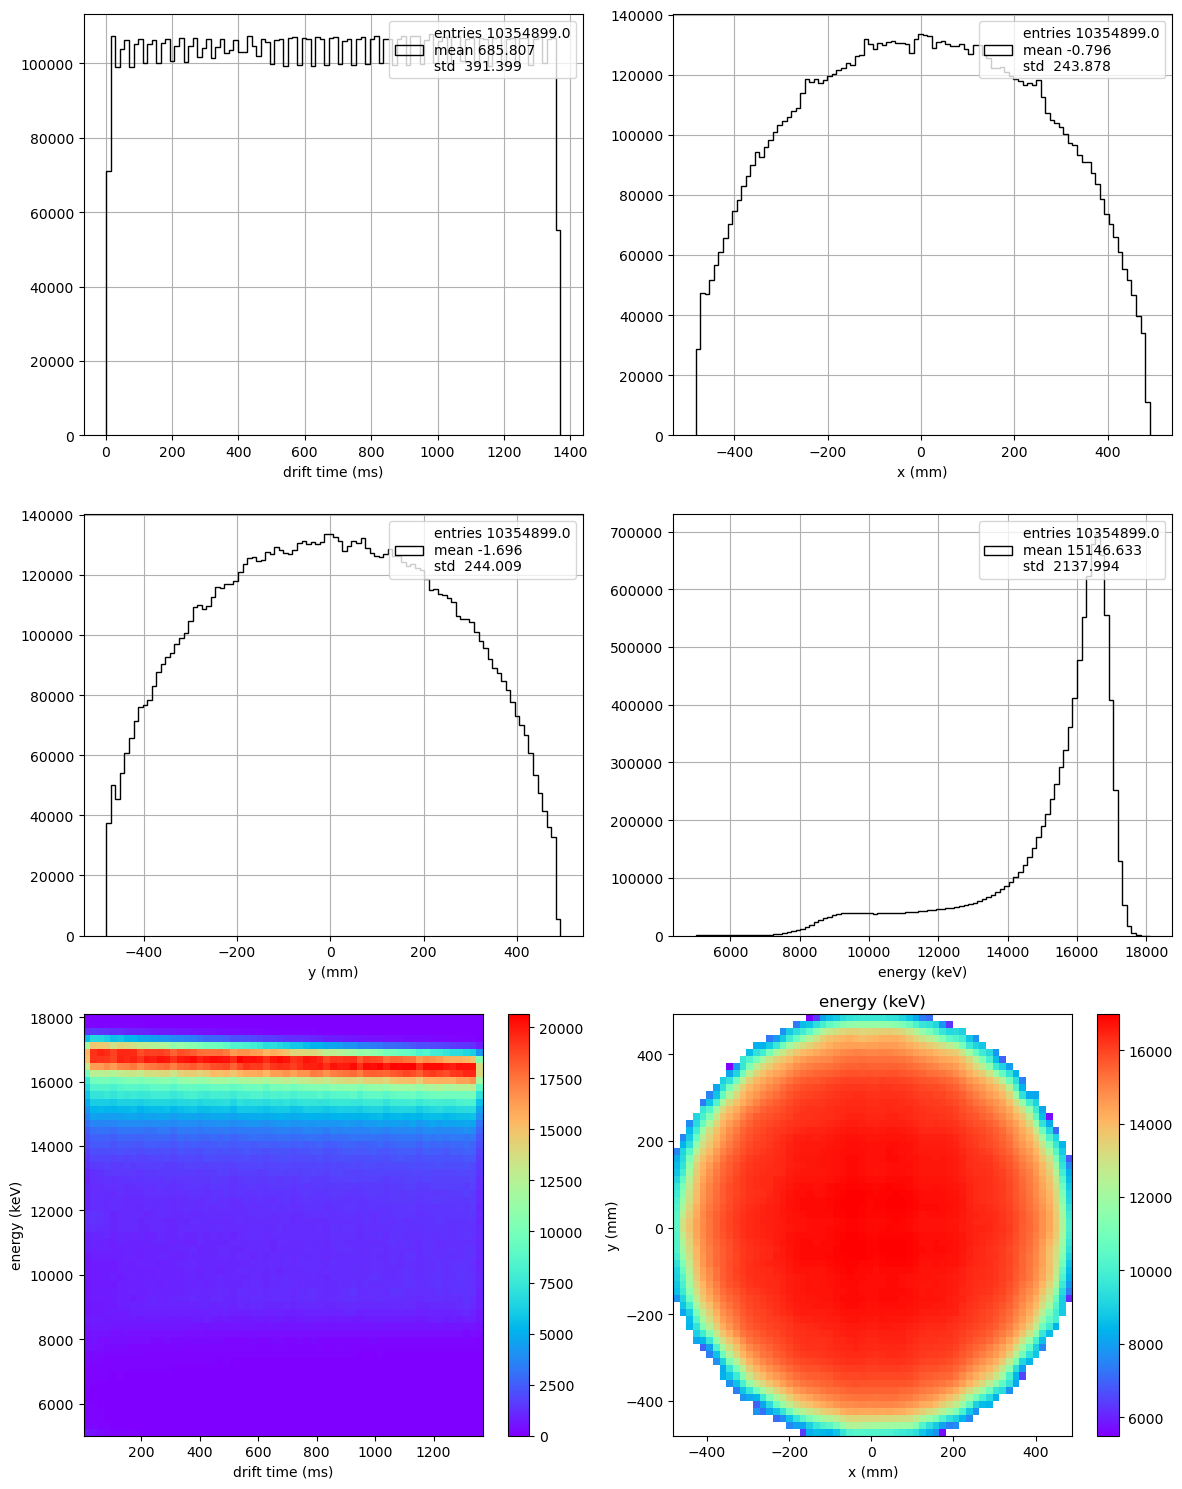

In [128]:
sel = sels['fidutial']
krana.plot_data(mkdst[sel], 60)

In [129]:
vdrift = np.max(mkdst[sel].z/mkdst[sel].dtime)
print('Drift velocity {:6.4f}'.format(vdrift))

Drift velocity 0.8700


## Kr Map

In [160]:
counts_min = 40
pitch      = 15.00
xmin       = -489.825
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  67 , range :  -489.825 ,  500.175


In [194]:
sel    = sels['fidutial']
coors  = mkdst[sel].x, mkdst[sel].y
energy = mkdst[sel].energy
dtime  = mkdst[sel].dtime
counts_min = 60
bins   = (xbins, xbins) 

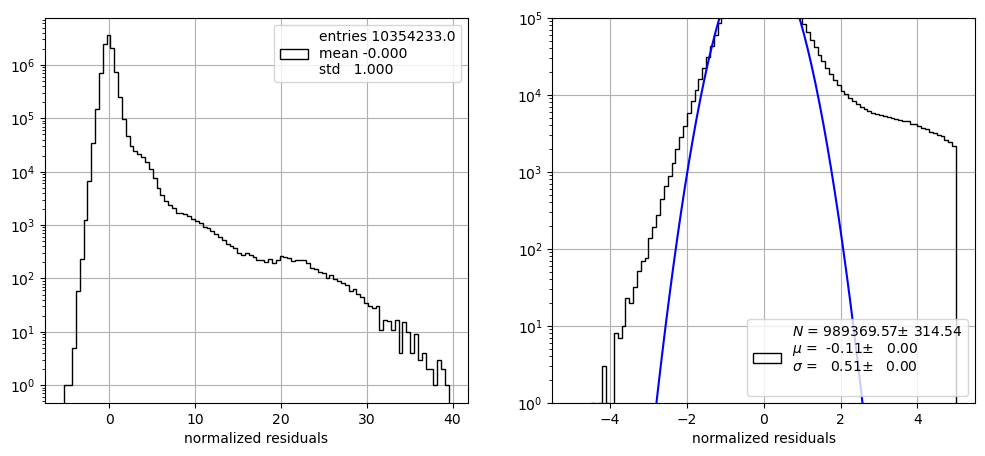

sigma 0.51 done  False  eff 98.01


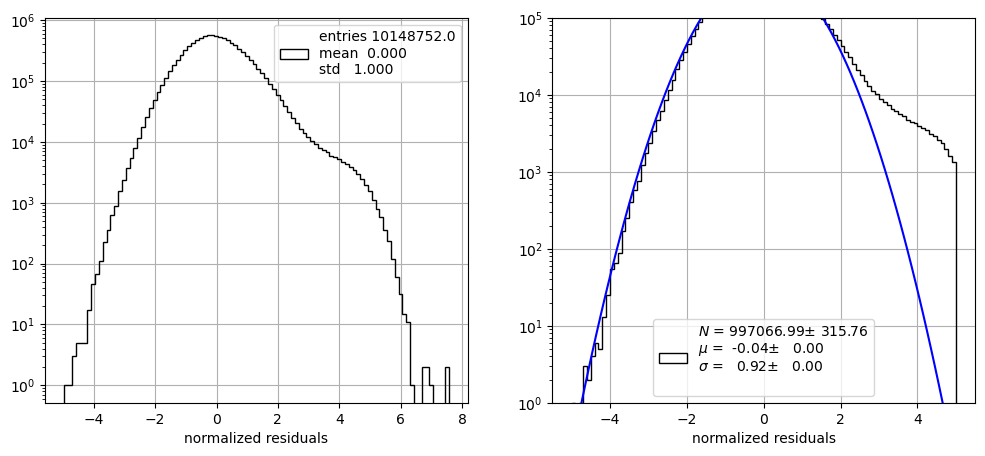

sigma 0.92 done  True  eff 100.00


In [195]:
min_sigma = 0.92
krmap, usel = krtool.clean_krmap(coors, dtime, energy, bins = bins, min_sigma = min_sigma, dt0 = None)

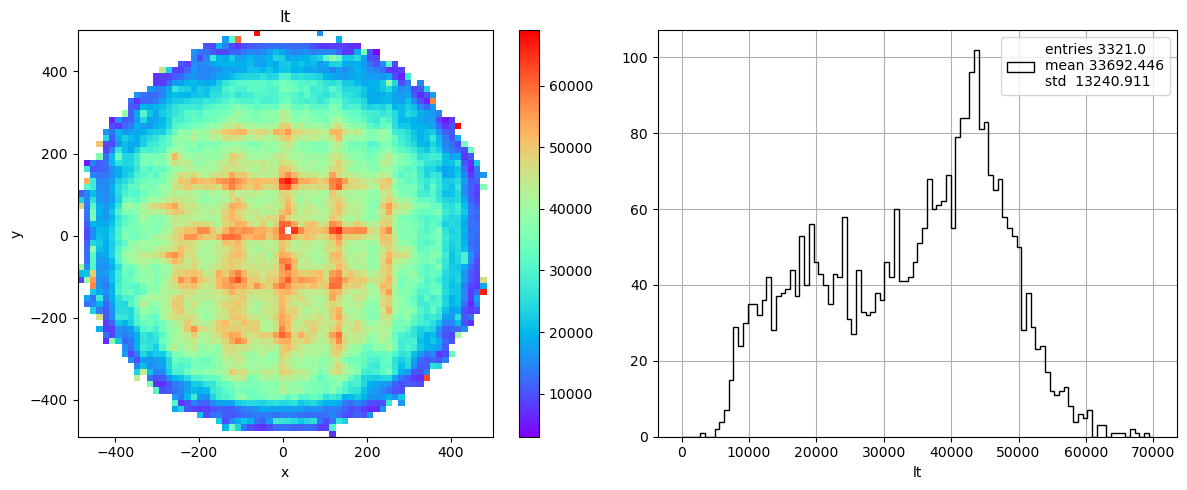

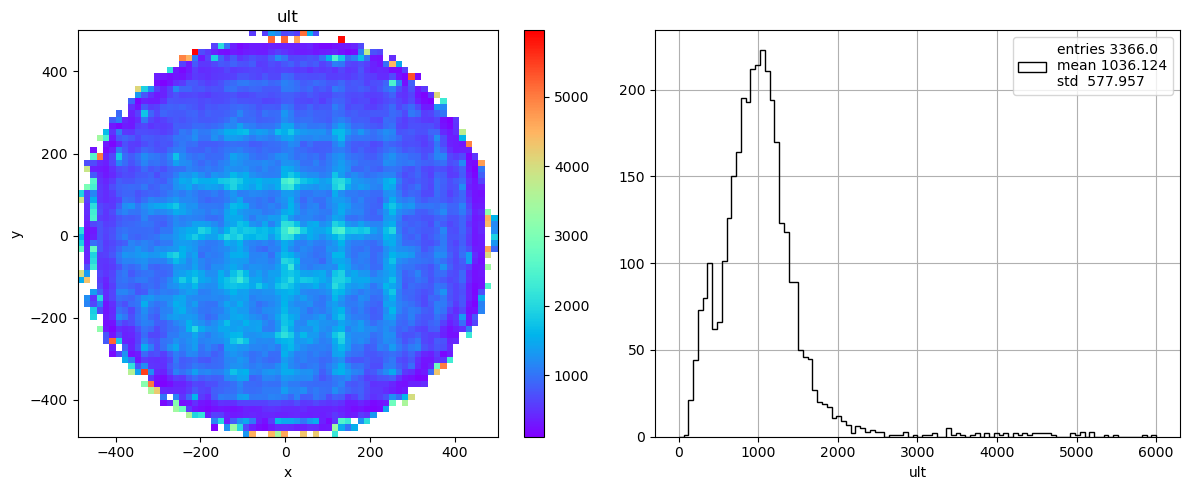

In [197]:
lt, ult = krtool.krmap_lifetime(krmap)
krtool.plot_xyvar(lt   , krmap.bin_edges, 'lt'  , mask = krmap.success, range = (0, 7e4));
krtool.plot_xyvar(ult  , krmap.bin_edges, 'ult' , mask = krmap.success, range = (0, 6e3))

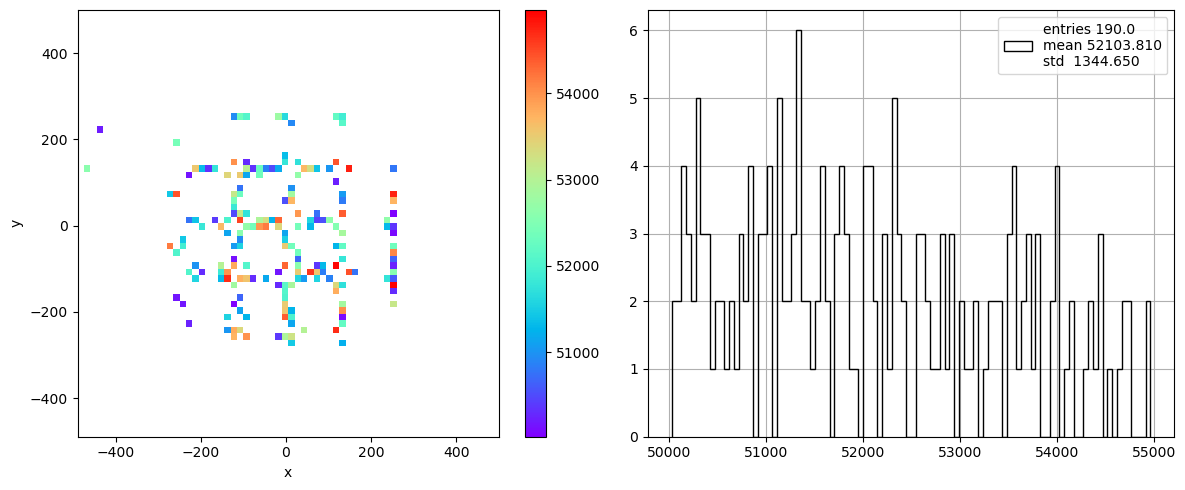

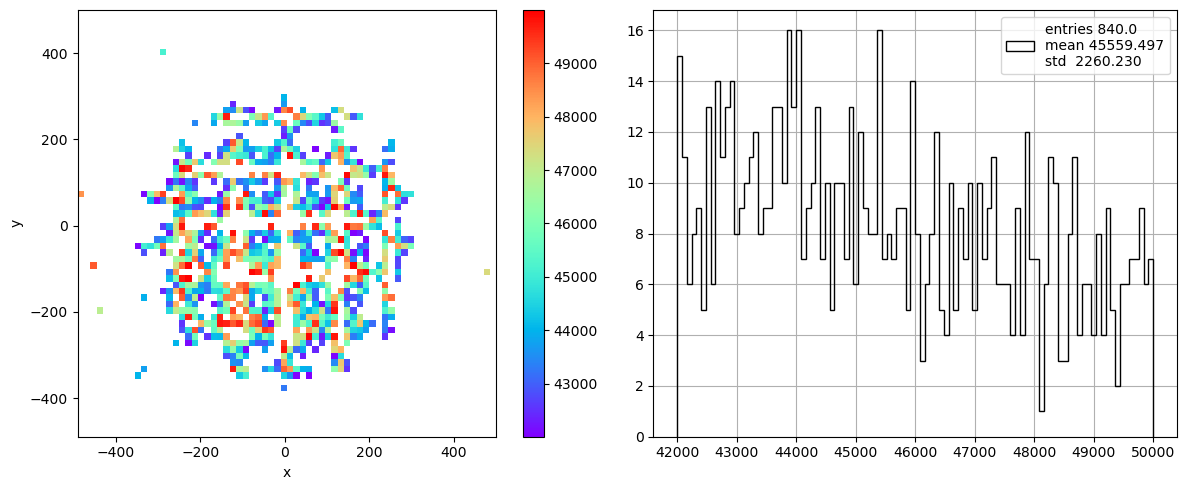

In [495]:
mask_lt1 = ut.in_range(lt, (50000, 55000))
np.sum(mask_lt1)
krtool.plot_xyvar(lt, bins, mask = mask_lt1)
mask_lt2 = ut.in_range(lt, (42000, 50000))
np.sum(mask_lt2)
krtool.plot_xyvar(lt, bins, mask = mask_lt2)

In [496]:
icoors = krtool.coors_index(coors, bins)
usel1  = krtool.coors_mask(icoors, mask_lt1)
usel2  = krtool.coors_mask(icoors, mask_lt2)

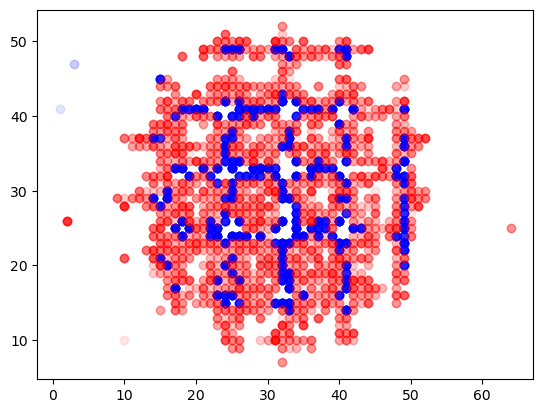

In [517]:
n = 5000
plt.scatter(icoors[0][usel1][:n], icoors[1][usel1][:n],alpha = 0.1, c = 'blue')
plt.scatter(icoors[0][usel2][:n], icoors[1][usel2][:n],alpha = 0.1, c = 'red')

(14000.0, 18000.0)

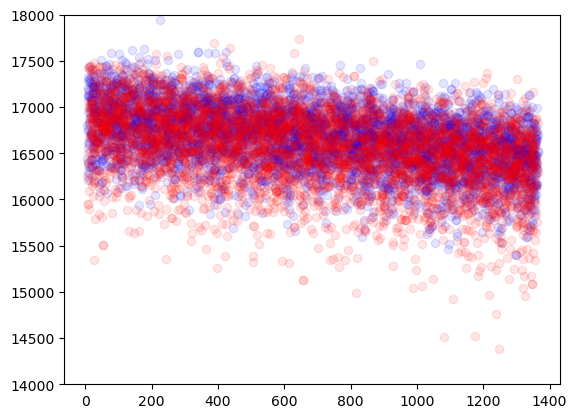

In [519]:
n = 5000
plt.scatter(dtime[usel1][:n], energy[usel1][:n], alpha = 0.1, c= 'blue')
plt.scatter(dtime[usel2][:n], energy[usel2][:n], alpha = 0.1, c= 'red')
plt.ylim((14000, 18000))

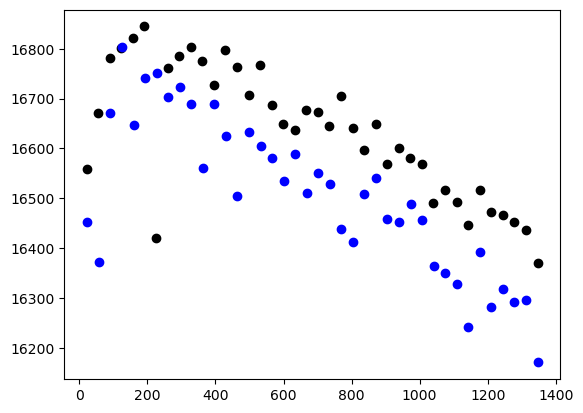

In [520]:
nbins, name = 40, 'lt (50, 55)'
z1, _  = prof.profile((dtime[usel1][:n],), energy[usel1][:n], nbins)
z2, _  = prof.profile((dtime[usel2][:n],), energy[usel2][:n], nbins)

plt.scatter(z1.bin_centers, z1.mean)
plt.scatter(z2.bin_centers, z2.mean)